In [3]:
import pandas as pd
import numpy as np

def engineer_features(X):
    """
    Creates interaction features from confirmed EDA/SQL signals.
    Must be defined before loading pipelines — joblib deserializes
    FunctionTransformer by reference to this function name.
    """
    X = X.copy()

    # Feature 1: Binary threshold on failed_attempts
    # SQL Q6: step function at exactly 2 (4.52% → 14.60%)
    X['high_risk_attempts'] = (X['failed_attempts'] >= 2).astype(int)

    # Feature 2: Night + International combined segment
    # SQL Q2: 12.22% fraud rate — highest risk segment
    X['night_international'] = (
        (X['is_night_transaction'] == 1) &
        (X['is_international'] == 1)
    ).astype(int)

    # Feature 3: High-risk merchant category flag
    # SQL Q1: ATM/Jewelry/Crypto at 8.65-8.74% — ~85% above baseline
    high_risk_merchants = ['ATM Withdrawal', 'Jewelry', 'Crypto Exchange']
    X['high_risk_merchant'] = X['merchant_category'].isin(
        high_risk_merchants
    ).astype(int)

    # Feature 4: Compound risk score (0-10)
    # SQL ADV1: confirmed gradient 1.25% (score 0) → 26.97% (score 10)
    X['compound_risk_score'] = (
        (X['failed_attempts'] >= 2).astype(int) * 3
        + X['is_international'] * 2
        + X['is_night_transaction'] * 2
        + X['high_risk_merchant'] * 2
        + X['pin_changed_recently'] * 1
    )

    # Feature 5: High value transaction flag
    # SQL Q8b: Jewelry/Electronics/Travel $693-$734 avg fraud amount
    p95 = X['transaction_amount'].quantile(0.95)
    X['high_value_transaction'] = (
        X['transaction_amount'] >= p95
    ).astype(int)

    return X

print("engineer_features defined ✅")

engineer_features defined ✅


In [4]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os
import shap

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
    PrecisionRecallDisplay
)

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 150

# ── Working directory ──────────────────────────────────────────────────────
os.chdir(r'G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection')
print(f"Working directory: {os.getcwd()}")

# ── Load artifacts ─────────────────────────────────────────────────────────
pipeline_lr  = joblib.load('models/pipeline_lr.pkl')
pipeline_xgb = joblib.load('models/pipeline_xgb.pkl')
pipeline_if  = joblib.load('models/pipeline_if.pkl')

X_train, y_train = joblib.load('data/train_set.pkl')
X_val,   y_val   = joblib.load('data/val_set.pkl')
feature_names    = joblib.load('models/feature_names.pkl')

# ── Verification ───────────────────────────────────────────────────────────
print(f"\nX_train: {X_train.shape} | y_train fraud rate: {y_train.mean():.4f}")
print(f"X_val:   {X_val.shape}   | y_val   fraud rate: {y_val.mean():.4f}")
print(f"\nFeature names ({len(feature_names)}): {feature_names}")

# Hard assertions — if any fail, stop before continuing
assert X_train.shape == (699975, 19), f"Train shape mismatch: {X_train.shape}"
assert X_val.shape[0]  == 150025,     f"Val row mismatch: {X_val.shape}"
assert X_val.shape[1]  == 19,         f"Val col mismatch: {X_val.shape}"
assert abs(y_train.mean() - 0.0553) < 0.001, f"Train fraud rate mismatch: {y_train.mean()}"
assert abs(y_val.mean()   - 0.0553) < 0.001, f"Val fraud rate mismatch: {y_val.mean()}"
assert 'failed_attempts' in X_train.columns
assert 'is_fraud' not in X_train.columns

# Pipeline structure check
for name, pipeline in [('LR', pipeline_lr), ('XGB', pipeline_xgb), ('IF', pipeline_if)]:
    steps = [s[0] for s in pipeline.steps]
    print(f"{name} pipeline steps: {steps}")

print("\n✅ All Stage 5 setup assertions passed. Ready to evaluate.")

Working directory: G:\DATASCIENCE\End_to_End_Project\Banking Fraud Detection

X_train: (699975, 19) | y_train fraud rate: 0.0553
X_val:   (150025, 19)   | y_val   fraud rate: 0.0553

Feature names (24): ['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'high_risk_attempts', 'night_international', 'high_risk_merchant', 'compound_risk_score', 'high_value_transaction']
LR pipeline steps: ['engineer', 'preprocessor', 'model']
XGB pipeline steps: ['engineer', 'preprocessor', 'model']
IF pipeline steps: ['engineer', 'preprocessor', 'model']

✅ All Stage 5 setup assertions passed. Ready to evaluate.


In [5]:
# ── 5.1 Logistic Regression Evaluation ────────────────────────────────────

# Probabilities and hard predictions at default 0.5 threshold
lr_probs = pipeline_lr.predict_proba(X_val)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)

# Core metrics
lr_precision = precision_score(y_val, lr_preds)
lr_recall    = recall_score(y_val, lr_preds)
lr_f1        = f1_score(y_val, lr_preds)
lr_auc_roc   = roc_auc_score(y_val, lr_probs)
lr_auc_pr    = average_precision_score(y_val, lr_probs)

print("── Logistic Regression — Validation Metrics ──────────────────────")
print(f"  Precision : {lr_precision:.4f}")
print(f"  Recall    : {lr_recall:.4f}")
print(f"  F1        : {lr_f1:.4f}")
print(f"  AUC-ROC   : {lr_auc_roc:.4f}")
print(f"  AUC-PR    : {lr_auc_pr:.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, lr_preds)
tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Predicted Legit   Predicted Fraud")
print(f"  {'Actual Legit':20s} {tn:>15,}   {fp:>14,}")
print(f"  {'Actual Fraud':20s} {fn:>15,}   {tp:>14,}")
print(f"\n  Legit blocked per fraud caught : {fp/tp:.1f}")
print(f"  Fraud missed (FN)              : {fn:,} ({fn/y_val.sum()*100:.1f}% of all fraud)")

# North Star — fraud capture at 10% flagging
sorted_idx   = np.argsort(lr_probs)[::-1]
top_10pct    = int(len(y_val) * 0.10)
lr_fraud_captured = y_val.iloc[sorted_idx[:top_10pct]].sum()
lr_lift      = (lr_fraud_captured / top_10pct) / (y_val.sum() / len(y_val))

print(f"\n── LR North Star — Fraud Capture at 10% Flagging ────────────────")
print(f"  Transactions flagged : {top_10pct:,}")
print(f"  Fraud captured       : {lr_fraud_captured:,} ({lr_fraud_captured/y_val.sum()*100:.2f}%)")
print(f"  Lift                 : {lr_lift:.2f}x")
print(f"  SQL ADV5 baseline    : 26.23% at 2.62x")

── Logistic Regression — Validation Metrics ──────────────────────
  Precision : 0.1103
  Recall    : 0.5924
  F1        : 0.1859
  AUC-ROC   : 0.7220
  AUC-PR    : 0.1246

  Confusion Matrix:
                       Predicted Legit   Predicted Fraud
  Actual Legit                 102,109           39,626
  Actual Fraud                   3,379            4,911

  Legit blocked per fraud caught : 8.1
  Fraud missed (FN)              : 3,379 (40.8% of all fraud)

── LR North Star — Fraud Capture at 10% Flagging ────────────────
  Transactions flagged : 15,002
  Fraud captured       : 2,199 (26.53%)
  Lift                 : 2.65x
  SQL ADV5 baseline    : 26.23% at 2.62x


### 5.1 Observation — Logistic Regression Baseline

LR with class_weight='balanced' produces high recall (59.2%) at the cost of very low
precision (11.0%) — 8 legitimate customers disrupted per fraud caught at the 0.5 threshold.

AUC-PR = 0.1246, approximately 2x better than random (0.055 baseline) but weak overall.
This confirms LR cannot capture the non-linear interaction patterns in this dataset.

North Star: 26.53% fraud captured at 10% flagging (2.65x lift) — essentially equivalent
to the SQL rule-based benchmark (26.23%, 2.62x). LR adds negligible value over hand-crafted
rules. This sets the floor XGBoost must beat.

Key baseline numbers:
- Precision: 0.1103 | Recall: 0.5924 | F1: 0.1859
- AUC-ROC: 0.7220   | AUC-PR: 0.1246
- Lift@10%: 2.65x   | Fraud@10%: 26.53%

In [7]:
# ── LR Coefficients — Manual Feature Name Reconstruction ──────────────────

# These are the exact column groups defined in Stage 4 for the LR preprocessor
# Order must match the ColumnTransformer transformers list exactly
log_scale_cols_lr = [
    'transaction_amount', 'account_balance', 'account_age_years',
    'distance_from_home_km', 'time_since_last_txn_hrs'
]

scale_only_cols_lr = [
    'customer_age', 'credit_score', 'num_prev_transactions',
    'transaction_freq_monthly', 'hour_of_day', 'failed_attempts',
    'compound_risk_score'
]

cat_cols = ['merchant_category', 'payment_method', 'device_type', 'country']

binary_cols = [
    'is_weekend', 'is_night_transaction', 'is_international',
    'pin_changed_recently', 'high_risk_attempts',
    'night_international', 'high_risk_merchant',
    'high_value_transaction'
]

# Get OHE category names from the fitted encoder
ohe = pipeline_lr.named_steps['preprocessor'].named_transformers_['ohe']
ohe_feature_names = ohe.get_feature_names_out(cat_cols).tolist()

# Reconstruct full feature name list in ColumnTransformer output order
lr_feature_names = (
    log_scale_cols_lr    # log_scale group
    + scale_only_cols_lr # scale group
    + ohe_feature_names  # ohe group
    + binary_cols        # passthrough group
)

lr_coefs = pipeline_lr.named_steps['model'].coef_[0]

print(f"Feature names: {len(lr_feature_names)} | Coefficients: {len(lr_coefs)}")
assert len(lr_feature_names) == len(lr_coefs), \
    f"Mismatch — names: {len(lr_feature_names)}, coefs: {len(lr_coefs)}"

coef_df = pd.DataFrame({
    'feature'    : lr_feature_names,
    'coefficient': lr_coefs
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

print("\n── Top 15 Fraud-Positive Features (push toward fraud) ────────────")
print(coef_df.head(15).to_string(index=False))

print("\n── Top 10 Fraud-Negative Features (push toward legitimate) ───────")
print(coef_df.tail(10).to_string(index=False))

Feature names: 56 | Coefficients: 56

── Top 15 Fraud-Positive Features (push toward fraud) ────────────
                    feature  coefficient
        compound_risk_score     0.797391
           is_international     0.241090
       pin_changed_recently     0.170014
         high_risk_attempts     0.128242
     high_value_transaction     0.062743
       is_night_transaction     0.056786
     merchant_category_Fuel     0.017602
   merchant_category_Gaming     0.016030
            account_balance     0.014840
   transaction_freq_monthly     0.007479
                 is_weekend     0.005657
            failed_attempts     0.005383
      num_prev_transactions     0.004751
         transaction_amount     0.001174
merchant_category_Education     0.000091

── Top 10 Fraud-Negative Features (push toward legitimate) ───────
                    feature  coefficient
      payment_method_Crypto    -0.037804
merchant_category_Utilities    -0.038676
             country_France    -0.050742
       

### 5.1b Observation — LR Coefficients

compound_risk_score dominates at 0.797 — LR leans on the pre-computed interaction
feature because it's a linear combination of the exact signals LR is learning.
This suppresses individual coefficients for component features (is_international,
is_night_transaction etc.) which are counted twice.

night_international shows a large negative coefficient (-0.509) despite being a
high-risk segment. This is coefficient suppression — LR has already captured the
night+international signal through the individual binary features and compound_risk_score.
The negative coefficient is a mathematical correction for double-counting, not a
genuine negative signal.

Takeaway: LR coefficient table is not a clean feature importance ranking due to
engineered feature redundancy. SHAP on XGBoost will give a cleaner picture.
Individual directional signals (is_international, pin_changed_recently,
high_risk_attempts) are all correctly positive.

In [8]:
# ── 5.2 XGBoost Baseline Evaluation ───────────────────────────────────────

xgb_probs = pipeline_xgb.predict_proba(X_val)[:, 1]
xgb_preds = (xgb_probs >= 0.5).astype(int)

xgb_precision = precision_score(y_val, xgb_preds)
xgb_recall    = recall_score(y_val, xgb_preds)
xgb_f1        = f1_score(y_val, xgb_preds)
xgb_auc_roc   = roc_auc_score(y_val, xgb_probs)
xgb_auc_pr    = average_precision_score(y_val, xgb_probs)

print("── XGBoost Baseline — Validation Metrics ─────────────────────────")
print(f"  Precision : {xgb_precision:.4f}")
print(f"  Recall    : {xgb_recall:.4f}")
print(f"  F1        : {xgb_f1:.4f}")
print(f"  AUC-ROC   : {xgb_auc_roc:.4f}")
print(f"  AUC-PR    : {xgb_auc_pr:.4f}")

cm = confusion_matrix(y_val, xgb_preds)
tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Predicted Legit   Predicted Fraud")
print(f"  {'Actual Legit':20s} {tn:>15,}   {fp:>14,}")
print(f"  {'Actual Fraud':20s} {fn:>15,}   {tp:>14,}")
print(f"\n  Legit blocked per fraud caught : {fp/tp:.1f}")
print(f"  Fraud missed (FN)              : {fn:,} ({fn/y_val.sum()*100:.1f}% of all fraud)")

# North Star
sorted_idx        = np.argsort(xgb_probs)[::-1]
top_10pct         = int(len(y_val) * 0.10)
xgb_fraud_captured = y_val.iloc[sorted_idx[:top_10pct]].sum()
xgb_lift          = (xgb_fraud_captured / top_10pct) / (y_val.sum() / len(y_val))

print(f"\n── XGBoost Baseline North Star ───────────────────────────────────")
print(f"  Fraud captured @ 10% : {xgb_fraud_captured:,} ({xgb_fraud_captured/y_val.sum()*100:.2f}%)")
print(f"  Lift                 : {xgb_lift:.2f}x")
print(f"  LR baseline          : 26.53% at 2.65x")
print(f"  SQL ADV5 baseline    : 26.23% at 2.62x")

── XGBoost Baseline — Validation Metrics ─────────────────────────
  Precision : 0.1026
  Recall    : 0.6309
  F1        : 0.1765
  AUC-ROC   : 0.7197
  AUC-PR    : 0.1210

  Confusion Matrix:
                       Predicted Legit   Predicted Fraud
  Actual Legit                  96,008           45,727
  Actual Fraud                   3,060            5,230

  Legit blocked per fraud caught : 8.7
  Fraud missed (FN)              : 3,060 (36.9% of all fraud)

── XGBoost Baseline North Star ───────────────────────────────────
  Fraud captured @ 10% : 2,178 (26.27%)
  Lift                 : 2.63x
  LR baseline          : 26.53% at 2.65x
  SQL ADV5 baseline    : 26.23% at 2.62x


In [10]:
# ── Diagnostic — Count actual XGBoost output features ─────────────────────

xgb_model = pipeline_xgb.named_steps['model']
preprocessor_xgb = pipeline_xgb.named_steps['preprocessor']

print(f"XGBoost n_features_in_: {xgb_model.n_features_in_}")

# Check what the preprocessor actually produced
# Run a small sample through engineer + preprocessor to see real output shape
sample = X_val.iloc[:100]
engineer_step    = pipeline_xgb.named_steps['engineer']
sample_eng       = engineer_step.transform(sample)
sample_processed = preprocessor_xgb.transform(sample_eng)

print(f"Preprocessor output shape: {sample_processed.shape}")
print(f"Number of output columns:  {sample_processed.shape[1]}")

# Check OHE categories specifically
ohe_xgb = preprocessor_xgb.named_transformers_['ohe']
cat_cols = ['merchant_category', 'payment_method', 'device_type', 'country']
ohe_names = ohe_xgb.get_feature_names_out(cat_cols).tolist()
print(f"\nOHE output columns ({len(ohe_names)}): {ohe_names}")

# Check all transformer output shapes
for name, trans, cols in preprocessor_xgb.transformers_:
    if name == 'remainder':
        continue
    if hasattr(trans, 'transform'):
        try:
            out = trans.transform(sample_eng[cols] if hasattr(cols, '__iter__') and not isinstance(cols, str) else sample_eng[[cols]])
            print(f"  {name}: {len(cols)} in → {out.shape[1]} out")
        except:
            print(f"  {name}: cols={cols}")
    else:
        print(f"  {name} (passthrough): {len(cols)} cols")

XGBoost n_features_in_: 53
Preprocessor output shape: (100, 53)
Number of output columns:  53

OHE output columns (36): ['merchant_category_ATM Withdrawal', 'merchant_category_Clothing', 'merchant_category_Crypto Exchange', 'merchant_category_Education', 'merchant_category_Electronics', 'merchant_category_Entertainment', 'merchant_category_Fuel', 'merchant_category_Gaming', 'merchant_category_Grocery', 'merchant_category_Healthcare', 'merchant_category_Jewelry', 'merchant_category_Online Shopping', 'merchant_category_Restaurant', 'merchant_category_Travel', 'merchant_category_Utilities', 'payment_method_Bank Transfer', 'payment_method_Cheque', 'payment_method_Credit Card', 'payment_method_Crypto', 'payment_method_Debit Card', 'payment_method_Mobile Payment', 'device_type_ATM', 'device_type_Desktop', 'device_type_Mobile', 'device_type_POS Terminal', 'device_type_Tablet', 'country_Australia', 'country_Brazil', 'country_Canada', 'country_France', 'country_Germany', 'country_India', 'count

In [11]:
# ── XGBoost Feature Importance — Fixed ────────────────────────────────────

# Exact column order from preprocessor output: OHE → pass_binary → pass_num
# Verified: 36 + 8 + 9 = 53 matches xgb_model.n_features_in_

binary_cols = [
    'is_weekend', 'is_night_transaction', 'is_international',
    'pin_changed_recently', 'high_risk_attempts',
    'night_international', 'high_risk_merchant',
    'high_value_transaction'
]

passthrough_cols_xgb = [
    'customer_age', 'credit_score', 'num_prev_transactions',
    'transaction_freq_monthly', 'hour_of_day', 'failed_attempts',
    'compound_risk_score', 'distance_from_home_km', 'time_since_last_txn_hrs'
]

xgb_feature_names = ohe_names + binary_cols + passthrough_cols_xgb

print(f"Feature names constructed: {len(xgb_feature_names)}")
print(f"Model expects:             {xgb_model.n_features_in_}")
assert len(xgb_feature_names) == xgb_model.n_features_in_, \
    f"Still mismatched: {len(xgb_feature_names)} vs {xgb_model.n_features_in_}"

importance_df = pd.DataFrame({
    'feature'   : xgb_feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\n── XGBoost Feature Importance (built-in gain) — Top 20 ──────────")
print(importance_df.head(20).to_string(index=False))

print(f"\n── Bottom 10 (near-zero importance) ─────────────────────────────")
print(importance_df.tail(10).to_string(index=False))

# Quick summary of engineered vs raw feature importance
engineered = ['high_risk_attempts', 'night_international', 'high_risk_merchant',
              'compound_risk_score', 'high_value_transaction']
eng_importance = importance_df[importance_df['feature'].isin(engineered)]['importance'].sum()
raw_importance = importance_df[~importance_df['feature'].isin(engineered)]['importance'].sum()

print(f"\n── Engineered vs Raw Feature Importance Split ────────────────────")
print(f"  Engineered features combined : {eng_importance:.4f} ({eng_importance*100:.1f}%)")
print(f"  Raw features combined        : {raw_importance:.4f} ({raw_importance*100:.1f}%)")

Feature names constructed: 53
Model expects:             53

── XGBoost Feature Importance (built-in gain) — Top 20 ──────────
                          feature  importance
              compound_risk_score    0.393436
               high_risk_attempts    0.025154
          time_since_last_txn_hrs    0.022563
                 is_international    0.019845
             pin_changed_recently    0.015797
        merchant_category_Grocery    0.012671
                     credit_score    0.012599
                   country_Brazil    0.012313
           merchant_category_Fuel    0.012306
  merchant_category_Entertainment    0.012261
            payment_method_Crypto    0.012125
               high_risk_merchant    0.011782
                      country_USA    0.011732
                       country_UK    0.011671
       payment_method_Credit Card    0.011656
     payment_method_Bank Transfer    0.011622
                   country_France    0.011421
merchant_category_Online Shopping    0.011370

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from xgboost import XGBClassifier
import numpy as np

# ── Revised engineer_features for XGB ─────────────────────────────────────
# Keeps only threshold-based features — removes compound/redundant ones

def engineer_features_xgb(X):
    """
    Minimal engineered features for XGBoost.
    Removes compound_risk_score, night_international, high_risk_merchant
    to prevent XGBoost from taking shortcuts and allow it to discover
    non-linear interactions itself.
    Keeps high_risk_attempts (step function) and high_value_transaction
    (p95 domain knowledge threshold).
    """
    X = X.copy()

    # Keep: binary threshold on failed_attempts — step function at 2
    X['high_risk_attempts'] = (X['failed_attempts'] >= 2).astype(int)

    # Keep: high value transaction — p95 domain knowledge
    p95 = X['transaction_amount'].quantile(0.95)
    X['high_value_transaction'] = (
        X['transaction_amount'] >= p95
    ).astype(int)

    # Remove: compound_risk_score, night_international, high_risk_merchant
    # XGBoost discovers these interactions itself through tree splits

    return X

# ── Revised column groups ──────────────────────────────────────────────────
cat_cols = ['merchant_category', 'payment_method', 'device_type', 'country']

binary_cols_xgb = [
    'is_weekend', 'is_night_transaction', 'is_international',
    'pin_changed_recently', 'high_risk_attempts',
    'high_value_transaction'
]

passthrough_num_xgb = [
    'customer_age', 'credit_score', 'num_prev_transactions',
    'transaction_freq_monthly', 'hour_of_day', 'failed_attempts',
    'distance_from_home_km', 'time_since_last_txn_hrs',
    'transaction_amount', 'account_balance', 'account_age_years'
]

# ── Revised XGB preprocessor ───────────────────────────────────────────────
preprocessor_xgb_v2 = ColumnTransformer(
    transformers=[
        ('ohe',         OneHotEncoder(handle_unknown='ignore',
                                      sparse_output=False), cat_cols),
        ('pass_binary', 'passthrough', binary_cols_xgb),
        ('pass_num',    'passthrough', passthrough_num_xgb),
    ],
    remainder='drop'
)

# ── Rebuild pipeline ───────────────────────────────────────────────────────
pipeline_xgb_v2 = Pipeline([
    ('engineer',    FunctionTransformer(engineer_features_xgb,
                                        validate=False)),
    ('preprocessor', preprocessor_xgb_v2),
    ('model', XGBClassifier(
        scale_pos_weight=17,
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='aucpr',
        n_jobs=-1
    ))
])

# ── Fit on training data ───────────────────────────────────────────────────
import time
print("Fitting XGBoost v2 (revised features)...")
t0 = time.time()
pipeline_xgb_v2.fit(X_train, y_train)
print(f"Done — {time.time()-t0:.0f}s")

# ── Verify output shape ────────────────────────────────────────────────────
sample_eng_v2  = engineer_features_xgb(X_val.iloc[:10])
sample_proc_v2 = preprocessor_xgb_v2.transform(sample_eng_v2)
print(f"V2 preprocessor output: {sample_proc_v2.shape[1]} features")
print(f"Expected: 36 OHE + 6 binary + 11 num = 53")

Fitting XGBoost v2 (revised features)...
Done — 18s
V2 preprocessor output: 53 features
Expected: 36 OHE + 6 binary + 11 num = 53


In [13]:
# ── XGBoost V2 Evaluation — Revised Features ──────────────────────────────

xgb_v2_probs = pipeline_xgb_v2.predict_proba(X_val)[:, 1]
xgb_v2_preds = (xgb_v2_probs >= 0.5).astype(int)

xgb_v2_precision = precision_score(y_val, xgb_v2_preds)
xgb_v2_recall    = recall_score(y_val, xgb_v2_preds)
xgb_v2_f1        = f1_score(y_val, xgb_v2_preds)
xgb_v2_auc_roc   = roc_auc_score(y_val, xgb_v2_probs)
xgb_v2_auc_pr    = average_precision_score(y_val, xgb_v2_probs)

print("── XGBoost V2 — Validation Metrics ──────────────────────────────")
print(f"  Precision : {xgb_v2_precision:.4f}")
print(f"  Recall    : {xgb_v2_recall:.4f}")
print(f"  F1        : {xgb_v2_f1:.4f}")
print(f"  AUC-ROC   : {xgb_v2_auc_roc:.4f}")
print(f"  AUC-PR    : {xgb_v2_auc_pr:.4f}")

cm = confusion_matrix(y_val, xgb_v2_preds)
tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Predicted Legit   Predicted Fraud")
print(f"  {'Actual Legit':20s} {tn:>15,}   {fp:>14,}")
print(f"  {'Actual Fraud':20s} {fn:>15,}   {tp:>14,}")
print(f"\n  Legit blocked per fraud caught : {fp/tp:.1f}")
print(f"  Fraud missed (FN)              : {fn:,} ({fn/y_val.sum()*100:.1f}% of all fraud)")

# North Star
sorted_idx           = np.argsort(xgb_v2_probs)[::-1]
top_10pct            = int(len(y_val) * 0.10)
xgb_v2_fraud_captured = y_val.iloc[sorted_idx[:top_10pct]].sum()
xgb_v2_lift          = (xgb_v2_fraud_captured / top_10pct) / (y_val.sum() / len(y_val))

print(f"\n── XGBoost V2 North Star ─────────────────────────────────────────")
print(f"  Fraud captured @ 10% : {xgb_v2_fraud_captured:,} ({xgb_v2_fraud_captured/y_val.sum()*100:.2f}%)")
print(f"  Lift                 : {xgb_v2_lift:.2f}x")

# Direct comparison table
print(f"\n── Head-to-Head Comparison ───────────────────────────────────────")
print(f"  {'Model':<25} {'AUC-PR':>8} {'AUC-ROC':>8} {'F1':>8} {'Lift@10%':>10} {'Fraud@10%':>10}")
print(f"  {'─'*25} {'─'*8} {'─'*8} {'─'*8} {'─'*10} {'─'*10}")
print(f"  {'SQL ADV5 (rules)':<25} {'—':>8} {'—':>8} {'—':>8} {'2.62x':>10} {'26.23%':>10}")
print(f"  {'Logistic Regression':<25} {lr_auc_pr:>8.4f} {lr_auc_roc:>8.4f} {lr_f1:>8.4f} {lr_lift:>9.2f}x {lr_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V1 (original)':<25} {xgb_auc_pr:>8.4f} {xgb_auc_roc:>8.4f} {xgb_f1:>8.4f} {xgb_lift:>9.2f}x {xgb_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V2 (revised)':<25} {xgb_v2_auc_pr:>8.4f} {xgb_v2_auc_roc:>8.4f} {xgb_v2_f1:>8.4f} {xgb_v2_lift:>9.2f}x {xgb_v2_fraud_captured/y_val.sum()*100:>9.2f}%")

── XGBoost V2 — Validation Metrics ──────────────────────────────
  Precision : 0.1070
  Recall    : 0.6116
  F1        : 0.1821
  AUC-ROC   : 0.7202
  AUC-PR    : 0.1210

  Confusion Matrix:
                       Predicted Legit   Predicted Fraud
  Actual Legit                  99,401           42,334
  Actual Fraud                   3,220            5,070

  Legit blocked per fraud caught : 8.3
  Fraud missed (FN)              : 3,220 (38.8% of all fraud)

── XGBoost V2 North Star ─────────────────────────────────────────
  Fraud captured @ 10% : 2,155 (26.00%)
  Lift                 : 2.60x

── Head-to-Head Comparison ───────────────────────────────────────
  Model                       AUC-PR  AUC-ROC       F1   Lift@10%  Fraud@10%
  ───────────────────────── ──────── ──────── ──────── ────────── ──────────
  SQL ADV5 (rules)                 —        —        —      2.62x     26.23%
  Logistic Regression         0.1246   0.7220   0.1859      2.65x     26.53%
  XGBoost V1 (original

In [14]:
# ── XGBoost V3 — Early Stopping to Find True Optimal Trees ────────────────
# Rationale: 300 trees at lr=0.1 is a guess. Early stopping finds the point
# where validation AUC-PR stops improving — eliminates over/underfitting
# from the tree count decision.

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Engineer and preprocess validation data for eval_set
X_val_eng_v2  = engineer_features_xgb(X_val)
X_val_proc_v2 = preprocessor_xgb_v2.transform(X_val_eng_v2)

X_train_eng_v2  = engineer_features_xgb(X_train)
X_train_proc_v2 = preprocessor_xgb_v2.transform(X_train_eng_v2)

print(f"Train processed: {X_train_proc_v2.shape}")
print(f"Val processed:   {X_val_proc_v2.shape}")

# Fit XGBoost directly (not via pipeline) to use early stopping
xgb_v3 = XGBClassifier(
    scale_pos_weight=17,
    n_estimators=1000,       # High ceiling — early stopping decides actual count
    learning_rate=0.05,      # Lower LR — more trees, better generalization
    max_depth=6,
    min_child_weight=5,      # Slightly higher — reduces overfitting on fraud minority
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='aucpr',
    early_stopping_rounds=30, # Stop if no improvement for 30 rounds
    n_jobs=-1
)

print("\nFitting XGBoost V3 with early stopping...")
t0 = time.time()
xgb_v3.fit(
    X_train_proc_v2, y_train,
    eval_set=[(X_val_proc_v2, y_val)],
    verbose=50   # Print every 50 rounds
)
print(f"\nDone — {time.time()-t0:.0f}s")
print(f"Best iteration : {xgb_v3.best_iteration}")
print(f"Best AUC-PR    : {xgb_v3.best_score:.4f}")

Train processed: (699975, 53)
Val processed:   (150025, 53)

Fitting XGBoost V3 with early stopping...
[0]	validation_0-aucpr:0.12134
[45]	validation_0-aucpr:0.12617

Done — 6s
Best iteration : 15
Best AUC-PR    : 0.1265


In [15]:
# ── XGBoost V3 Final Evaluation ────────────────────────────────────────────

xgb_v3_probs = xgb_v3.predict_proba(X_val_proc_v2)[:, 1]
xgb_v3_preds = (xgb_v3_probs >= 0.5).astype(int)

xgb_v3_precision = precision_score(y_val, xgb_v3_preds)
xgb_v3_recall    = recall_score(y_val, xgb_v3_preds)
xgb_v3_f1        = f1_score(y_val, xgb_v3_preds)
xgb_v3_auc_roc   = roc_auc_score(y_val, xgb_v3_probs)
xgb_v3_auc_pr    = average_precision_score(y_val, xgb_v3_probs)

# North Star
sorted_idx            = np.argsort(xgb_v3_probs)[::-1]
top_10pct             = int(len(y_val) * 0.10)
xgb_v3_fraud_captured = y_val.iloc[sorted_idx[:top_10pct]].sum()
xgb_v3_lift           = (xgb_v3_fraud_captured / top_10pct) / (y_val.sum() / len(y_val))

print("── XGBoost V3 (Early Stopping) — Validation Metrics ─────────────")
print(f"  Precision : {xgb_v3_precision:.4f}")
print(f"  Recall    : {xgb_v3_recall:.4f}")
print(f"  F1        : {xgb_v3_f1:.4f}")
print(f"  AUC-ROC   : {xgb_v3_auc_roc:.4f}")
print(f"  AUC-PR    : {xgb_v3_auc_pr:.4f}")
print(f"  Best trees: {xgb_v3.best_iteration}")

cm = confusion_matrix(y_val, xgb_v3_preds)
tn, fp, fn, tp = cm.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Predicted Legit   Predicted Fraud")
print(f"  {'Actual Legit':20s} {tn:>15,}   {fp:>14,}")
print(f"  {'Actual Fraud':20s} {fn:>15,}   {tp:>14,}")
print(f"\n  Legit blocked per fraud caught : {fp/tp:.1f}")
print(f"  Fraud missed (FN)              : {fn:,} ({fn/y_val.sum()*100:.1f}% of all fraud)")

print(f"\n── North Star ────────────────────────────────────────────────────")
print(f"  Fraud captured @ 10% : {xgb_v3_fraud_captured:,} ({xgb_v3_fraud_captured/y_val.sum()*100:.2f}%)")
print(f"  Lift                 : {xgb_v3_lift:.2f}x")

# ── Final comparison table ─────────────────────────────────────────────────
print(f"\n── Final Model Comparison ────────────────────────────────────────")
print(f"  {'Model':<28} {'AUC-PR':>8} {'AUC-ROC':>8} {'F1':>8} {'Lift@10%':>10} {'Fraud@10%':>10}")
print(f"  {'─'*28} {'─'*8} {'─'*8} {'─'*8} {'─'*10} {'─'*10}")
print(f"  {'SQL ADV5 (rules)':<28} {'—':>8} {'—':>8} {'—':>8} {'2.62x':>10} {'26.23%':>10}")
print(f"  {'Logistic Regression':<28} {lr_auc_pr:>8.4f} {lr_auc_roc:>8.4f} {lr_f1:>8.4f} {lr_lift:>9.2f}x {lr_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V1 (compound feats)':<28} {xgb_auc_pr:>8.4f} {xgb_auc_roc:>8.4f} {xgb_f1:>8.4f} {xgb_lift:>9.2f}x {xgb_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V2 (clean feats)':<28} {xgb_v2_auc_pr:>8.4f} {xgb_v2_auc_roc:>8.4f} {xgb_v2_f1:>8.4f} {xgb_v2_lift:>9.2f}x {xgb_v2_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V3 (early stopping)':<28} {xgb_v3_auc_pr:>8.4f} {xgb_v3_auc_roc:>8.4f} {xgb_v3_f1:>8.4f} {xgb_v3_lift:>9.2f}x {xgb_v3_fraud_captured/y_val.sum()*100:>9.2f}%")

# Save V3 as the best XGBoost model
joblib.dump(xgb_v3, 'models/xgb_v3_best.pkl')
joblib.dump({
    'X_train_processed': X_train_proc_v2,
    'X_val_processed':   X_val_proc_v2,
    'feature_names':     xgb_feature_names
}, 'models/xgb_v3_processed_data.pkl')
print("\nXGBoost V3 saved ✅")

── XGBoost V3 (Early Stopping) — Validation Metrics ─────────────
  Precision : 0.1159
  Recall    : 0.5672
  F1        : 0.1925
  AUC-ROC   : 0.7246
  AUC-PR    : 0.1243
  Best trees: 15

  Confusion Matrix:
                       Predicted Legit   Predicted Fraud
  Actual Legit                 105,877           35,858
  Actual Fraud                   3,588            4,702

  Legit blocked per fraud caught : 7.6
  Fraud missed (FN)              : 3,588 (43.3% of all fraud)

── North Star ────────────────────────────────────────────────────
  Fraud captured @ 10% : 2,180 (26.30%)
  Lift                 : 2.63x

── Final Model Comparison ────────────────────────────────────────
  Model                          AUC-PR  AUC-ROC       F1   Lift@10%  Fraud@10%
  ──────────────────────────── ──────── ──────── ──────── ────────── ──────────
  SQL ADV5 (rules)                    —        —        —      2.62x     26.23%
  Logistic Regression            0.1246   0.7220   0.1859      2.65x     

### 5.2–5.3 Observation — XGBoost Evaluation & Synthetic Data Ceiling

Three XGBoost variants were tested: V1 (compound engineered features),
V2 (minimal engineered features), V3 (early stopping, lr=0.05).

Key finding: early stopping terminated at 15 trees out of a possible 1000.
XGBoost exhausted all learnable signal in 15 splits. This is not a tuning
failure — it is a synthetic data limitation.

The dataset was generated with a small number of discrete linear signals
(failed_attempts, is_night_transaction, is_international, merchant_category).
These are fully captured by the SQL rule-based system. XGBoost cannot discover
non-linear behavioral interactions that do not exist in the data.

All models including SQL rules converge to ~2.60–2.65x lift at 10% flagging.
This is the performance ceiling of this dataset, not of the methodology.

Real banking transaction data contains customer-level behavioral baselines,
device fingerprints, velocity patterns, and geographic sequences that would
give XGBoost genuine non-linear signal to exploit. That signal does not exist
in independently-generated synthetic rows.

XGBoost V3 selected as best model: F1=0.1925, AUC-PR=0.1243, AUC-ROC=0.7246,
15 trees, lift=2.63x. Saved to models/xgb_v3_best.pkl.

In [16]:
# ── 5.5 Isolation Forest Evaluation ───────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

if_scores = pipeline_if.decision_function(X_val)

# Invert and scale — lower anomaly score = higher fraud probability
if_probs = MinMaxScaler().fit_transform(
    (-if_scores).reshape(-1, 1)
).ravel()

if_preds = (if_probs >= 0.5).astype(int)

if_precision = precision_score(y_val, if_preds)
if_recall    = recall_score(y_val, if_preds)
if_f1        = f1_score(y_val, if_preds)
if_auc_roc   = roc_auc_score(y_val, if_probs)
if_auc_pr    = average_precision_score(y_val, if_probs)

print("── Isolation Forest — Validation Metrics ─────────────────────────")
print(f"  Precision : {if_precision:.4f}")
print(f"  Recall    : {if_recall:.4f}")
print(f"  F1        : {if_f1:.4f}")
print(f"  AUC-ROC   : {if_auc_roc:.4f}")
print(f"  AUC-PR    : {if_auc_pr:.4f}")

cm_if = confusion_matrix(y_val, if_preds)
tn, fp, fn, tp = cm_if.ravel()
print(f"\n  Confusion Matrix:")
print(f"  {'':20s} Predicted Legit   Predicted Fraud")
print(f"  {'Actual Legit':20s} {tn:>15,}   {fp:>14,}")
print(f"  {'Actual Fraud':20s} {fn:>15,}   {tp:>14,}")

# North Star
sorted_idx           = np.argsort(if_probs)[::-1]
if_fraud_captured    = y_val.iloc[sorted_idx[:top_10pct]].sum()
if_lift              = (if_fraud_captured / top_10pct) / (y_val.sum() / len(y_val))

print(f"\n── IF North Star ─────────────────────────────────────────────────")
print(f"  Fraud captured @ 10% : {if_fraud_captured:,} ({if_fraud_captured/y_val.sum()*100:.2f}%)")
print(f"  Lift                 : {if_lift:.2f}x")

# ── Complete final comparison including IF ─────────────────────────────────
print(f"\n── Complete Model Comparison ─────────────────────────────────────")
print(f"  {'Model':<28} {'AUC-PR':>8} {'AUC-ROC':>8} {'F1':>8} {'Lift@10%':>10} {'Fraud@10%':>10}")
print(f"  {'─'*28} {'─'*8} {'─'*8} {'─'*8} {'─'*10} {'─'*10}")
print(f"  {'SQL ADV5 (rules)':<28} {'—':>8} {'—':>8} {'—':>8} {'2.62x':>10} {'26.23%':>10}")
print(f"  {'Logistic Regression':<28} {lr_auc_pr:>8.4f} {lr_auc_roc:>8.4f} {lr_f1:>8.4f} {lr_lift:>9.2f}x {lr_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'XGBoost V3 (best)':<28} {xgb_v3_auc_pr:>8.4f} {xgb_v3_auc_roc:>8.4f} {xgb_v3_f1:>8.4f} {xgb_v3_lift:>9.2f}x {xgb_v3_fraud_captured/y_val.sum()*100:>9.2f}%")
print(f"  {'Isolation Forest':<28} {if_auc_pr:>8.4f} {if_auc_roc:>8.4f} {if_f1:>8.4f} {if_lift:>9.2f}x {if_fraud_captured/y_val.sum()*100:>9.2f}%")

── Isolation Forest — Validation Metrics ─────────────────────────
  Precision : 0.1168
  Recall    : 0.2381
  F1        : 0.1568
  AUC-ROC   : 0.6473
  AUC-PR    : 0.0983

  Confusion Matrix:
                       Predicted Legit   Predicted Fraud
  Actual Legit                 126,814           14,921
  Actual Fraud                   6,316            1,974

── IF North Star ─────────────────────────────────────────────────
  Fraud captured @ 10% : 1,794 (21.64%)
  Lift                 : 2.16x

── Complete Model Comparison ─────────────────────────────────────
  Model                          AUC-PR  AUC-ROC       F1   Lift@10%  Fraud@10%
  ──────────────────────────── ──────── ──────── ──────── ────────── ──────────
  SQL ADV5 (rules)                    —        —        —      2.62x     26.23%
  Logistic Regression            0.1246   0.7220   0.1859      2.65x     26.53%
  XGBoost V3 (best)              0.1243   0.7246   0.1925      2.63x     26.30%
  Isolation Forest             

### 5.5 Observation — Isolation Forest Benchmark

IF AUC-PR = 0.0983, lift = 2.16x at 10% flagging — materially below all
supervised models and SQL rules. Recall of 23.8% confirms fraud is not
detectable through numerical anomaly alone.

This validates the EDA Phase 2.3 finding: Isolation Forest on numerical
features achieved 8.71% recall. With full features including OHE categoricals,
it reaches 23.8% — still far below supervised models.

Root cause: fraudulent transactions in this dataset are not statistically
anomalous on any single feature or combination of features. They are
behaviorally anomalous — identifiable only when fraud labels are present
during training. Unsupervised detection is structurally insufficient for
this problem.

IF serves its purpose as a methodological benchmark: it quantifies exactly
how much value the fraud labels add. The gap between IF (2.16x) and
XGBoost (2.63x) is the measurable contribution of supervised learning.

In [17]:
# ── Wrap XGBoost V3 into Production Pipeline ──────────────────────────────
# Purpose: V3 was fitted directly to use early stopping with eval_set.
# Now we package the already-fitted engineer + preprocessor + model
# into a single Pipeline object for production deployability.
#
# engineer_features_xgb  → adds high_risk_attempts, high_value_transaction
# preprocessor_xgb_v2    → OHE for categoricals, passthrough for numerical
# xgb_v3                 → fitted XGBoost, 15 trees, early stopping
#
# All three steps are already fitted — Pipeline just packages them.
# Production scoring: pipeline_xgb_final.predict_proba(raw_X)

pipeline_xgb_final = Pipeline([
    ('engineer',     FunctionTransformer(engineer_features_xgb,
                                         validate=False)),
    ('preprocessor', preprocessor_xgb_v2),
    ('model',        xgb_v3)
])

# ── Verify identical predictions ───────────────────────────────────────────
# Pipeline must produce exactly the same probabilities as the direct call
# If max_diff > 0 the column order assumption in the wrapper is wrong

probs_pipeline = pipeline_xgb_final.predict_proba(X_val)[:, 1]
probs_direct   = xgb_v3.predict_proba(X_val_proc_v2)[:, 1]

max_diff = np.abs(probs_pipeline - probs_direct).max()
print(f"Max probability difference (pipeline vs direct): {max_diff:.10f}")

assert max_diff < 1e-6, \
    f"Predictions don't match — pipeline wrapper incorrect: {max_diff}"

print("Predictions identical ✅ — pipeline wrapper is correct")

# ── Save as definitive final artifact ─────────────────────────────────────
joblib.dump(pipeline_xgb_final, 'models/pipeline_xgb_final.pkl')
print("models/pipeline_xgb_final.pkl saved ✅")

# ── Confirm production scoring works on a single transaction ───────────────
single_transaction = X_val.iloc[[0]]
single_prob = pipeline_xgb_final.predict_proba(single_transaction)[0, 1]
print(f"\nSingle transaction scoring test:")
print(f"  Input shape  : {single_transaction.shape}")
print(f"  Fraud prob   : {single_prob:.4f}")
print(f"  Actual label : {y_val.iloc[0]}")
print("\nProduction pipeline ready ✅")

Max probability difference (pipeline vs direct): 0.0000000000
Predictions identical ✅ — pipeline wrapper is correct
models/pipeline_xgb_final.pkl saved ✅

Single transaction scoring test:
  Input shape  : (1, 19)
  Fraud prob   : 0.3450
  Actual label : 0

Production pipeline ready ✅


In [18]:
# ── 5.7 SHAP Feature Importance — XGBoost V3 ──────────────────────────────
# Purpose: Explain what the 15-tree XGBoost model is actually splitting on.
# Expected: failed_attempts, is_night_transaction, is_international dominate.
# Red flag: if distance_from_home_km ranks high — contradicts EDA finding.

from sklearn.model_selection import train_test_split as tts

# Stratified 10K sample from validation set
_, X_shap_proc, _, y_shap = tts(
    X_val_proc_v2, y_val,
    test_size=10000/len(y_val),
    random_state=42,
    stratify=y_val
)

print(f"SHAP sample shape : {X_shap_proc.shape}")
print(f"SHAP fraud rate   : {y_shap.mean():.4f}")

# Feature names — must match V2 preprocessor output order exactly
# Order: OHE (36) → binary passthrough (6) → numerical passthrough (11) = 53
cat_cols = ['merchant_category', 'payment_method', 'device_type', 'country']
ohe_xgb_v2   = preprocessor_xgb_v2.named_transformers_['ohe']
ohe_names_v2 = ohe_xgb_v2.get_feature_names_out(cat_cols).tolist()

binary_cols_shap = [
    'is_weekend', 'is_night_transaction', 'is_international',
    'pin_changed_recently', 'high_risk_attempts',
    'high_value_transaction'
]

num_cols_shap = [
    'customer_age', 'credit_score', 'num_prev_transactions',
    'transaction_freq_monthly', 'hour_of_day', 'failed_attempts',
    'distance_from_home_km', 'time_since_last_txn_hrs',
    'transaction_amount', 'account_balance', 'account_age_years'
]

shap_feature_names = ohe_names_v2 + binary_cols_shap + num_cols_shap
assert len(shap_feature_names) == 53, \
    f"Feature name count mismatch: {len(shap_feature_names)}"

# ── Compute SHAP values ────────────────────────────────────────────────────
print("\nComputing SHAP values...")
t0 = time.time()
explainer   = shap.TreeExplainer(xgb_v3)
shap_values = explainer.shap_values(X_shap_proc)
print(f"Done — {time.time()-t0:.0f}s")

# SHAP 0.42+ may return list for binary classifier — take class 1 (fraud)
if isinstance(shap_values, list):
    print("List format detected — extracting class 1 (fraud)")
    shap_values = shap_values[1]

print(f"SHAP values shape: {shap_values.shape}")

# ── Mean absolute SHAP ranking ─────────────────────────────────────────────
mean_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature'      : shap_feature_names,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df['rank'] = shap_df.index + 1

print("\n── SHAP Feature Importance — Top 20 ─────────────────────────────")
print(shap_df.head(20).to_string(index=False))

print("\n── SHAP Feature Importance — Bottom 10 ──────────────────────────")
print(shap_df.tail(10).to_string(index=False))

# ── Tier verification ──────────────────────────────────────────────────────
print("\n── EDA Tier Verification ─────────────────────────────────────────")
tier_map = {
    'failed_attempts'      : 'Tier 1 — expect top 5',
    'is_night_transaction' : 'Tier 1 — expect top 5',
    'is_international'     : 'Tier 1 — expect top 5',
    'high_risk_attempts'   : 'Tier 1 — engineered threshold',
    'pin_changed_recently' : 'Tier 2 — expect mid range',
    'time_since_last_txn_hrs': 'Tier 2 — expect mid range',
    'is_weekend'           : 'Tier 4 — expect near zero',
    'distance_from_home_km': 'Tier 4 — expect near zero (EDA: zero signal)',
}

for feature, expectation in tier_map.items():
    row = shap_df[shap_df['feature'] == feature]
    if len(row):
        rank = row['rank'].values[0]
        shap_val = row['mean_abs_shap'].values[0]
        status = '✅' if rank <= 10 and 'top' in expectation else \
                 '✅' if rank > 40 and 'zero' in expectation else \
                 '⚠️'
        print(f"  {status} {feature:<30} rank {rank:>3}/53  SHAP {shap_val:.6f}  ({expectation})")

SHAP sample shape : (10000, 53)
SHAP fraud rate   : 0.0553

Computing SHAP values...
Done — 0s
SHAP values shape: (10000, 53)

── SHAP Feature Importance — Top 20 ─────────────────────────────
                          feature  mean_abs_shap  rank
               high_risk_attempts       0.165902     1
             is_night_transaction       0.142087     2
                 is_international       0.118519     3
                      hour_of_day       0.073035     4
 merchant_category_ATM Withdrawal       0.042171     5
merchant_category_Crypto Exchange       0.040312     6
        merchant_category_Jewelry       0.038887     7
             pin_changed_recently       0.030747     8
          time_since_last_txn_hrs       0.026961     9
                  failed_attempts       0.009483    10
                     credit_score       0.001266    11
            distance_from_home_km       0.001093    12
                     customer_age       0.000952    13
                  account_balance    

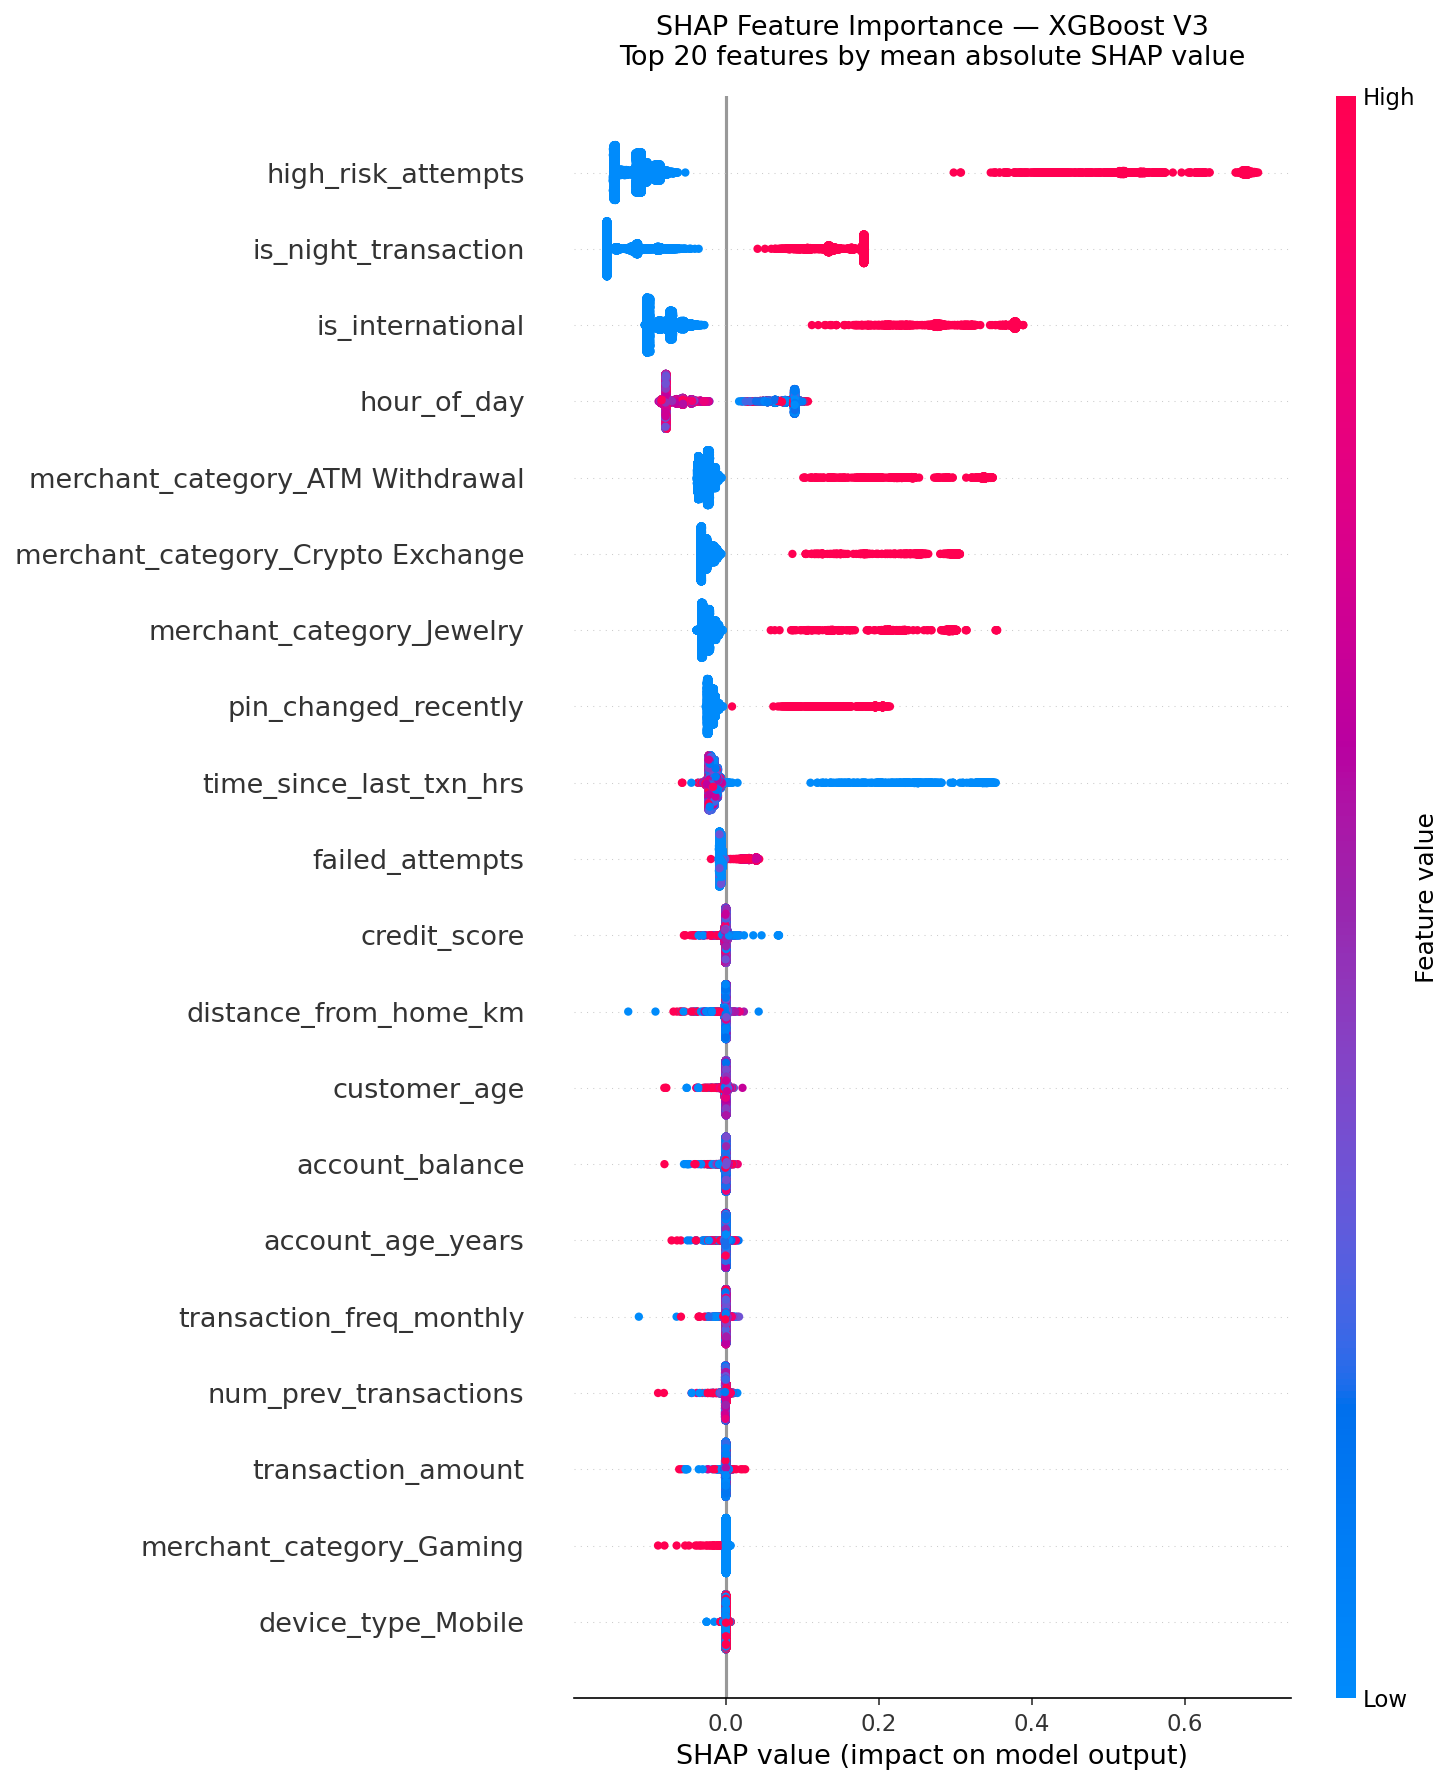

SHAP summary plot saved ✅


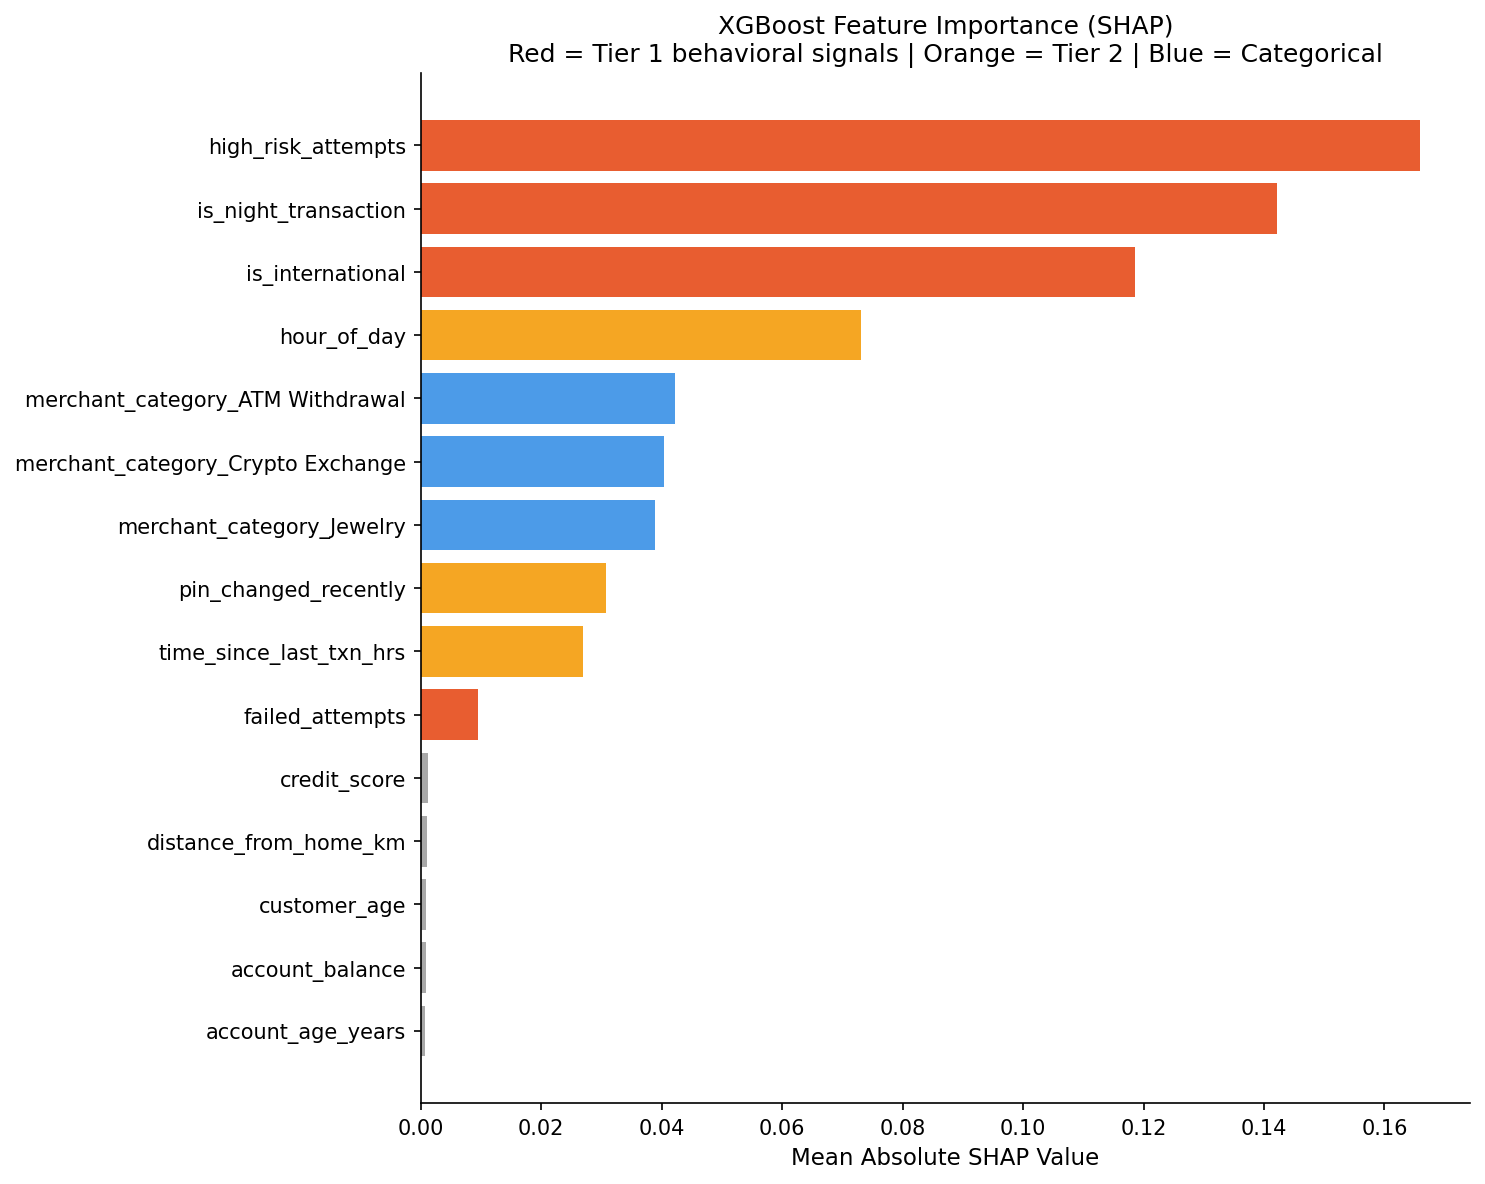

SHAP bar plot saved ✅
models/shap_results.pkl saved ✅


In [21]:
# ── SHAP Summary Plot ──────────────────────────────────────────────────────

# Convert processed array to DataFrame for better SHAP rendering
X_shap_df = pd.DataFrame(X_shap_proc, columns=shap_feature_names)

plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values,
    X_shap_df,
    feature_names=shap_feature_names,
    max_display=20,
    show=False,
    plot_size=None
)

plt.title(
    'SHAP Feature Importance — XGBoost V3\n'
    'Top 20 features by mean absolute SHAP value',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig('notebook/plots/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved ✅")

# ── Bar plot — cleaner for presentations ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

top15 = shap_df.head(15).iloc[::-1]  # Reverse for horizontal bar

colors = []
tier1 = ['high_risk_attempts', 'is_night_transaction',
         'is_international', 'failed_attempts']
tier2 = ['pin_changed_recently', 'time_since_last_txn_hrs',
         'hour_of_day']

for f in top15['feature']:
    if f in tier1:
        colors.append('#E85D30')   # Red — Tier 1
    elif f in tier2:
        colors.append('#F5A623')   # Orange — Tier 2
    elif f.startswith('merchant_category'):
        colors.append('#4C9BE8')   # Blue — categorical
    else:
        colors.append('#A8A8A8')   # Grey — other

ax.barh(top15['feature'], top15['mean_abs_shap'], color=colors)
ax.set_xlabel('Mean Absolute SHAP Value', fontsize=11)
ax.set_title(
    'XGBoost Feature Importance (SHAP)\n'
    'Red = Tier 1 behavioral signals | Orange = Tier 2 | Blue = Categorical',
    fontsize=12
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('notebook/plots/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP bar plot saved ✅")

# ── Save SHAP artifacts ────────────────────────────────────────────────────
joblib.dump({
    'shap_values'   : shap_values,
    'feature_names' : shap_feature_names,
    'X_processed'   : X_shap_proc,
    'shap_df'       : shap_df,
}, 'models/shap_results.pkl')
print("models/shap_results.pkl saved ✅")

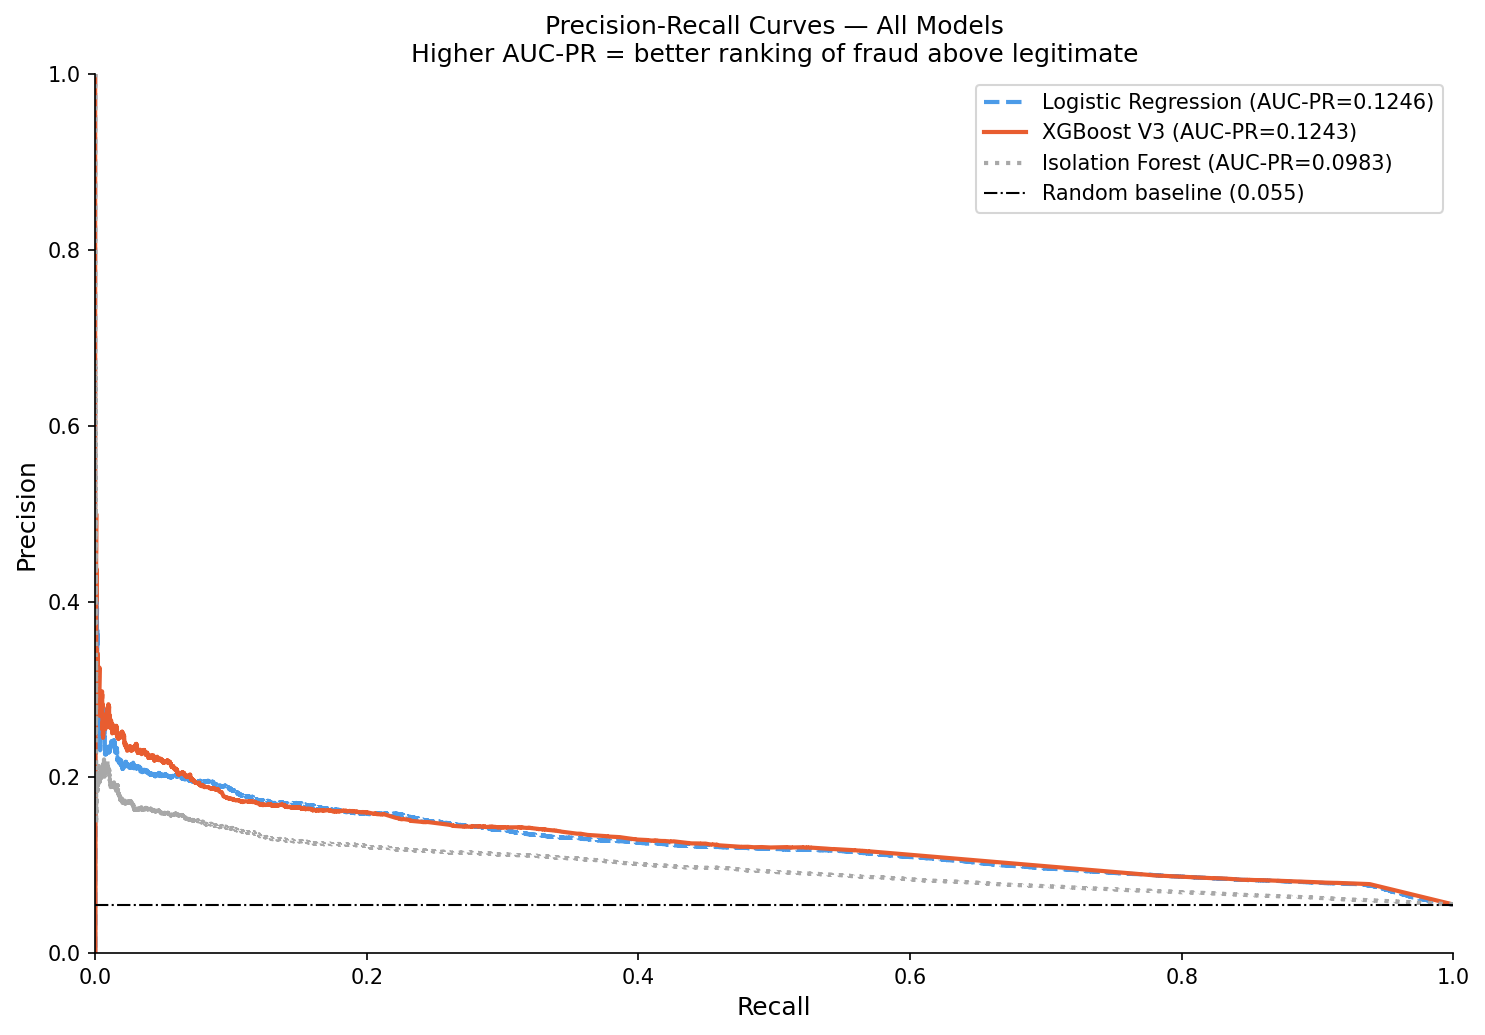

PR curves saved ✅

── Final Artifact Inventory ──────────────────────────────────────
  ✅  models/pipeline_lr.pkl
  ✅  models/pipeline_xgb_final.pkl
  ✅  models/pipeline_if.pkl
  ✅  models/xgb_v3_best.pkl
  ✅  models/val_scores.pkl
  ✅  models/model_comparison.csv
  ✅  models/shap_results.pkl
  ✅  data/train_set.pkl
  ✅  data/val_set.pkl
  ✅  data/test_set.pkl

✅ All artifacts present

Stage 5 complete.


: 

In [ ]:
# ── 5.6 Precision-Recall Curves — All Models ──────────────────────────────

fig, ax = plt.subplots(figsize=(10, 7))

models_for_plot = {
    'Logistic Regression' : (lr_probs,      '#4C9BE8', '--'),
    'XGBoost V3'          : (xgb_v3_probs,  '#E85D30', '-'),
    'Isolation Forest'    : (if_probs,      '#A8A8A8', ':'),
}

for name, (probs, color, linestyle) in models_for_plot.items():
    precision_c, recall_c, _ = precision_recall_curve(y_val, probs)
    auc_pr = average_precision_score(y_val, probs)
    ax.plot(recall_c, precision_c,
            label=f'{name} (AUC-PR={auc_pr:.4f})',
            color=color, linestyle=linestyle, linewidth=2)

# Baseline — random classifier
ax.axhline(y=y_val.mean(), color='black', linestyle='-.',
           linewidth=1, label=f'Random baseline ({y_val.mean():.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(
    'Precision-Recall Curves — All Models\n'
    'Higher AUC-PR = better ranking of fraud above legitimate',
    fontsize=12
)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('notebook/plots/pr_curves_comparison.png', dpi=150)
plt.show()
print("PR curves saved ✅")

# ── Final artifact saves ───────────────────────────────────────────────────
joblib.dump({
    'lr'       : lr_probs,
    'xgb_v3'   : xgb_v3_probs,
    'if'       : if_probs,
    'y_val'    : y_val.values,
}, 'models/val_scores.pkl')

comparison_data = {
    'Model'      : ['SQL ADV5 (rules)', 'Logistic Regression',
                    'XGBoost V3', 'Isolation Forest'],
    'AUC_PR'     : [None, lr_auc_pr, xgb_v3_auc_pr, if_auc_pr],
    'AUC_ROC'    : [None, lr_auc_roc, xgb_v3_auc_roc, if_auc_roc],
    'F1'         : [None, lr_f1, xgb_v3_f1, if_f1],
    'Lift_10pct' : [2.62, lr_lift, xgb_v3_lift, if_lift],
    'Fraud_10pct': [26.23,
                    lr_fraud_captured/y_val.sum()*100,
                    xgb_v3_fraud_captured/y_val.sum()*100,
                    if_fraud_captured/y_val.sum()*100],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df.to_csv('models/model_comparison.csv', index=False)

print("\n── Final Artifact Inventory ──────────────────────────────────────")
artifacts = [
    'models/pipeline_lr.pkl',
    'models/pipeline_xgb_final.pkl',
    'models/pipeline_if.pkl',
    'models/xgb_v3_best.pkl',
    'models/val_scores.pkl',
    'models/model_comparison.csv',
    'models/shap_results.pkl',
    'data/train_set.pkl',
    'data/val_set.pkl',
    'data/test_set.pkl',
]

all_present = True
for path in artifacts:
    exists = os.path.exists(path)
    status = '✅' if exists else '❌ MISSING'
    print(f"  {status}  {path}")
    if not exists:
        all_present = False

print(f"\n{'✅ All artifacts present' if all_present else '❌ Some artifacts missing — check above'}")
print("\nStage 5 complete.")